<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.


Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.


In [3]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

Your models understand only numbers and shapes.


In [4]:
# 1) Scalars, vectors, matrices, tensors
# Scalar (rank 0 tensor)
import tensorflow as tf
import numpy as np

scalar = tf.constant(7)

# Vector (rank 1 tensor)
vector = tf.constant([10, 20, 30])

# Matrix (rank 2 tensor)
matrix = tf.constant([
    [1., 2.],
    [3., 4.]
])

# Tensor (rank 3)
tensor = tf.constant([
    [[1], [2]],
    [[3], [4]]
])

print("Scalar shape:", scalar.shape)
print("Vector shape:", vector.shape)
print("Matrix shape:", matrix.shape)
print("Tensor shape:", tensor.shape)

Scalar shape: ()
Vector shape: (3,)
Matrix shape: (2, 2)
Tensor shape: (2, 2, 1)


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?


In [8]:
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB

print("Shape:", img_batch.shape)
print("Rank:", img_batch.ndim)

Shape: (32, 64, 64, 3)
Rank: 4


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.


In [10]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats

print("x16:", x16)
print("y32:", y32)

x16: tf.Tensor([1.7 7.4], shape=(2,), dtype=float16)
y32: tf.Tensor([ 7. 10.], shape=(2,), dtype=float32)


A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.


In [12]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

print("Last column:", last_col)
print("Expanded shape:", expanded.shape)
print("Squeezed shape:", squeezed.shape)

Last column: tf.Tensor([7 4], shape=(2,), dtype=int32)
Expanded shape: (2, 2, 1)
Squeezed shape: (2, 2)


picks all rows.
-1 selects the last column. last_col has shape (2,).

<b>Reshaping:</b>

expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).<br>
squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).


In [13]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, \* operate per position. This is different from matrix multiplication (tf.matmul).


Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks.


In [ ]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

# Multiply X and Yᵀ
result = tf.matmul(X, tf.transpose(Y))
print(result)


tf.Tensor(
[[ 23.  29.  35.]
 [ 53.  67.  81.]
 [ 83. 105. 127.]], shape=(3, 3), dtype=float32)


In [20]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "sum:", tf.reduce_sum(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy())

min: 8 max: 85 sum: 352 mean: 35.2


- These are used in loss calculations and metrics.


<b>Extra example of why should we change int to float:</b>


In [22]:

M = tf.constant([[2., 3.], [4., 5.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[3. 4.]
[2.5 4.5]


In [ ]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)
print(oh)   # oh = One hot 

tf.Tensor(
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]], shape=(4, 4), dtype=float32)


Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]


In [51]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.


In [52]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.


We use Matplotlib for visualization.


In [53]:
#import tensorflow as tf
#import numpy as np
import matplotlib.pyplot as plt

In [54]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20., -18., ..., 20.]
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">


Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).


In [55]:
# Train/test split (simple)
X_train, y_train = X[:20], y[:20]
X_test,  y_test  = X[20:], y[20:]

Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines.

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models.

API in this case means a set of classes and methods you call to build neural networks.


In [56]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop.
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.


In [28]:
# 2) COMPILE
model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)

model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting.
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras.


In [58]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - loss: 10.5526 - mae: 10.5526
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10.5326 - mae: 10.5326
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10.5126 - mae: 10.5126
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 10.4926 - mae: 10.4926
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 10.4726 - mae: 10.4726
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 10.4526 - mae: 10.4526
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 10.4326 - mae: 10.4326
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 10.4126 - mae: 10.4126
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 10.3926 - mae: 10.3926
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 10.3726 - mae: 10.3726
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.3526 - mae: 10.3526
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 10.3326 - mae: 10.3326
Epoch 13/200
1/1 ━━━━━━━

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br>
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.


In [59]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 16.199737548828125


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap


Test MAE: 2.6178035736083984
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


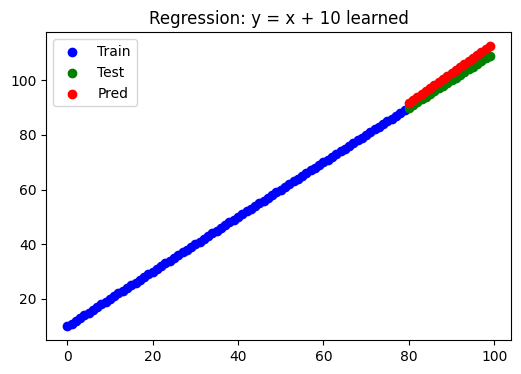

In [36]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.arange(0, 100)
y = X + 10

# Train / Test split
X_train = X[:80].reshape(-1,1)
y_train = y[:80]

X_test = X[80:].reshape(-1,1)
y_test = y[80:]

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mae',
    metrics=['mae']
)

# Train
model.fit(X_train, y_train, epochs=200, verbose=0)

# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)

# Predict
y_pred = model.predict(X_test).squeeze()

# Plot
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test, y_test, c='g', label='Test')
plt.scatter(X_test, y_pred, c='r', label='Pred')
plt.legend()
plt.title("Regression: y = x + 10 learned")
plt.show()



### Now the regression model is working correctly


- Initially, the regression model was not producing correct predictions. The predicted values (red points) were far from the actual test values (green points), indicating that the model had not learned the relationship 𝑦 = 𝑥 + 10
- This happened because the model configuration was not optimal for learning the pattern in the data.

* Next I have used Adam optimizer, Increased the number of training epochs and Mean Absolute Error (MAE)
  After these changes, the model successfully learned the relationship


HOMEWORK: Fix the regression model


<h1>Classification</h1>


Test accuracy: 1.000


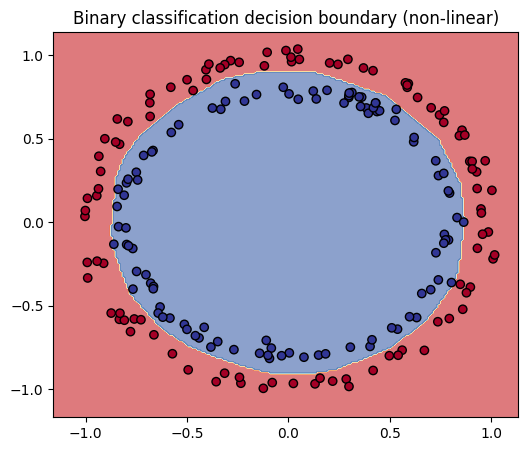

In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()


- This figure shows the decision boundary learned by the neural network for a binary classification problem. Its a non-linear classification problem.
  - Inner circle = class 0 (blue dots) and Outer circle = class 1 (red dots)

- Background colors show the region predicted by the model.
  - Blue region → predicted class 0
  - Red region → predicted class 1

  Dots represent the actual test data points.

The white circular boundary shows where the model switches its prediction between the two classes.

The model correctly learned a circular boundary, separating the inner points from the outer points.

- The reported test accuracy confirms that the model can correctly classify most of the points.

#### This experiment demonstrates that neural networks can learn complex non-linear decision boundaries, which traditional linear models like logistic regression without feature transformation cannot easily represent.


Test accuracy: 0.8810999989509583
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


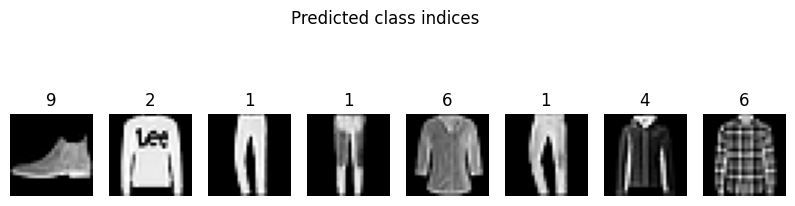

In [42]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0

# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


- The figure shows 8 test images from the Fashion-MNIST dataset and the class index predicted by the model for each image.
  - Fashion-MNIST contains 10 clothing categories, each represented by an integer label from 0 to 9

* Test accuracy 0.866% means the model correctly classified about 86.6% of the test images.

* The predicted values shown above each image represent the class indices produced by the model's softmax output layer. Each index corresponds to one of the ten clothing categories in the Fashion-MNIST dataset.

The model architecture consists of a Flatten layer followed by a dense hidden layer with ReLU activation and a softmax output layer. While this architecture can learn general patterns, it does not capture spatial features as effectively as convolutional neural networks, which explains why the accuracy is moderate rather than extremely high.

#### The predictions demonstrate that the model can recognize common clothing items


Test accuracy: 0.9695000052452087
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


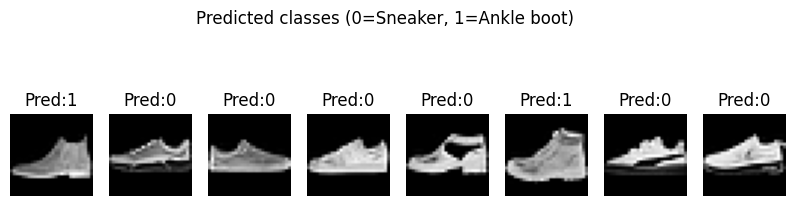

In [45]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show predictions on a few test images
preds = model.predict(x_test[:8]).squeeze()
pred_labels = (preds > 0.5).astype(int)

plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Pred:{pred_labels[i]}")
    plt.axis("off")

plt.suptitle("Predicted classes (0=Sneaker, 1=Ankle boot)")
plt.show()


- In this experiment, the Fashion-MNIST dataset was converted into a binary classification problem.

  Here, Class 7 = Sneaker (label = 0)
  Class 9 = Ankle boot (label = 1)

- A Convolutional Neural Network (CNN) has been used:
  - Conv2D layers extract spatial features such as edges and shapes.

  - MaxPooling layers reduce spatial dimensions and highlight dominant features.

  - Flatten + Dense layers perform the final classification.

  - The sigmoid output layer produces a probability for the binary classes.

- The model achieved a test accuracy of about 97%, its a bit higher than previous; because...
  - The model only needs to distinguish between two classes instead of ten
  - These two categories are visually different, makes them easier for the model to separate
  - CNN architecture captures spatial features like detects edges, curves, and shapes


Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7135 - loss: 0.6656 - val_accuracy: 0.8013 - val_loss: 0.5143
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8281 - loss: 0.4355 - val_accuracy: 0.8573 - val_loss: 0.3866
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8579 - loss: 0.3635 - val_accuracy: 0.8840 - val_loss: 0.3268
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8827 - loss: 0.3012 - val_accuracy: 0.8940 - val_loss: 0.3051
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9004 - loss: 0.2597 - val_accuracy: 0.9060 - val_loss: 0.2704
Test accuracy (tiny CNN): 0.8930000066757202


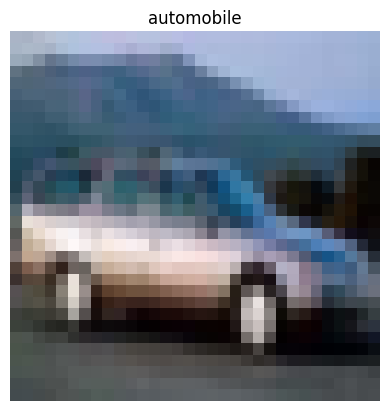

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)

# Show a few preds on test images
class_names = ["airplane", "automobile", "bird"]


plt.imshow(x_train[0])
plt.title(class_names[y_train[0]])
plt.axis("off")
plt.show()

- In this experiment, a small Convolutional Neural Network (CNN) was trained on the CIFAR-10 dataset, but only the first three classes were used

- The model was trained for 5 epochs with the Adam optimizer and sparse categorical cross-entropy loss, which is suitable when labels are integer class indices.

- The training accuracy improved from ~71% to ~89%, and the validation accuracy reached ~90%, showing that the model learned useful visual features. The final test accuracy is about 88.4%, meaning the model correctly classified around 88% of the unseen test images


Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


/Users/wazed/Semester 4/Pipeline project/IoT Pipeline-Wazed/Implementing-IoT-Pipeline-Wazed/ML_Task/tf-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3438 - loss: 1.0331 - val_accuracy: 0.5208 - val_loss: 0.9863
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6354 - loss: 0.9619 - val_accuracy: 0.6979 - val_loss: 0.9177
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6693 - loss: 0.8970 - val_accuracy: 0.6979 - val_loss: 0.8571
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6797 - loss: 0.8390 - val_accuracy: 0.7812 - val_loss: 0.8021
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8958 - loss: 0.7859 - val_accuracy: 1.0000 - val_loss: 0.7512
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.7358 - val_accuracy: 1.0000 - val_loss: 0.7012
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.6849 - val_accuracy: 1.0000 - val_loss: 0.6497
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.6341 - val_accuracy: 1.0000 - val_loss: 0.5993


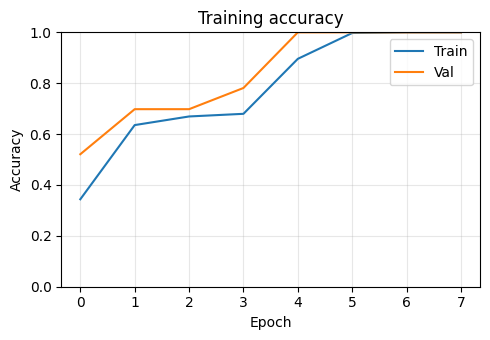

Test accuracy: 1.000


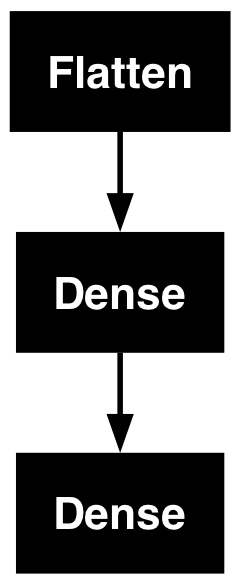

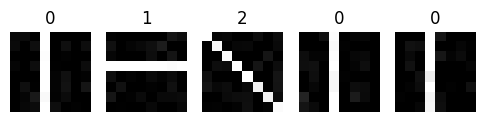

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Small MLP model
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — no params
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy (train vs val)
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
plot_model(model, to_file="mlp_tiny.png")
display(Image("mlp_tiny.png"))

plt.figure(figsize=(6,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()


- The dataset contains synthetic 8×8 grayscale images representing three patterns:
  vertical bar (class 0), horizontal bar (class 1), and diagonal line (class 2).
  The displayed images confirm that the generated samples match the expected
  patterns with small added noise.

- The model visualization step failed because the Graphviz dependency required
  by TensorFlow's plot_model function was not installed, so the file
  "mlp_tiny.png" could not be generated.


Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


Model: "tiny_parallel_mlp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8, 8, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 8)         │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         27 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7344 - loss: 0.9767 - val_accuracy: 0.9792 - val_loss: 0.9429
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.9242 - val_accuracy: 1.0000 - val_loss: 0.8875
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9896 - loss: 0.8698 - val_accuracy: 1.0000 - val_loss: 0.8314
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9948 - loss: 0.8155 - val_accuracy: 1.0000 - val_loss: 0.7758
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.7624 - val_accuracy: 1.0000 - val_loss: 0.7217
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.7109 - val_accuracy: 1.0000 - val_loss: 0.6697
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.6617 - val_accuracy: 1.0000 - val_loss: 0.6205
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.6155 - val_accuracy: 1.0000 - val_loss: 0.5748


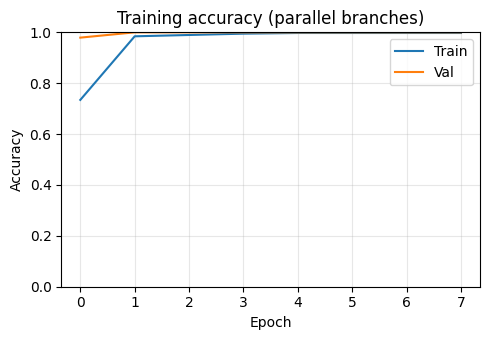

Test accuracy: 1.000


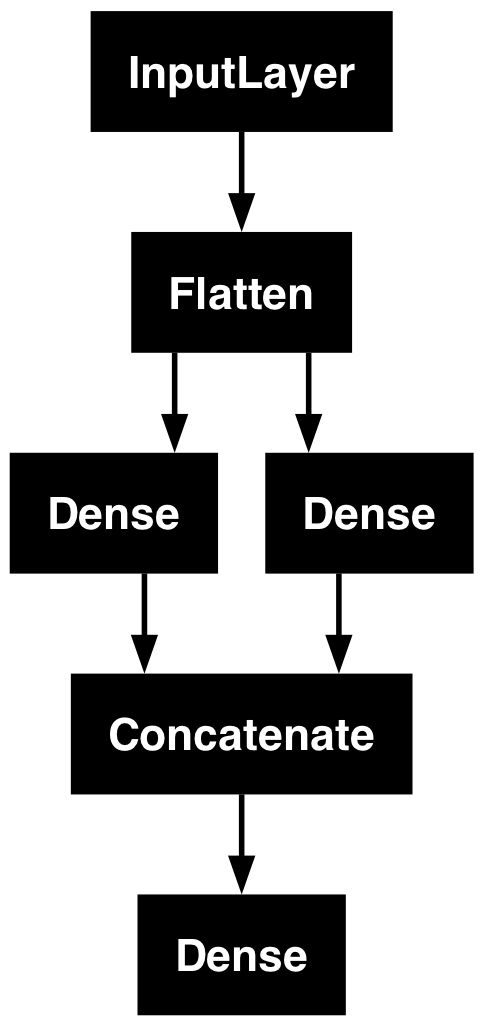

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Parallel-branches MLP (Functional API)
inputs = keras.Input(shape=(8, 8, 1), name="input")
x = layers.Flatten(name="flatten")(inputs)          # (None, 64) — params: 0

# Branch A: Dense(4)
branch_a = layers.Dense(4, activation="relu", name="branchA_dense")(x)  # params: 64*4 + 4 = 260

# Branch B: Dense(4)
branch_b = layers.Dense(4, activation="relu", name="branchB_dense")(x)  # params: 64*4 + 4 = 260

# Merge (concatenate)
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# Output: Dense(3)
outputs = layers.Dense(3, activation="softmax", name="output")(merged)

model = keras.Model(inputs, outputs, name="tiny_parallel_mlp")

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (parallel branches)")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
plot_model(model, to_file="parallel_mlp.png")
display(Image("parallel_mlp.png"))


- A synthetic dataset of 8×8 grayscale images was generated containing three patterns:
  - Class 0: Vertical bar
  - Class 1: Horizontal bar
  - Class 2: Diagonal line

Each class contains 200 samples, resulting in 600 total images. The dataset was shuffled and split into 80% training (480 samples) and 20% testing (120 samples).

- A parallel-branch MLP was implemented using the Keras Functional API
  - Total 547 trainable parameters.

- The model was trained for 8 epochs with Adam optimizer and sparse categorical cross-entropy loss.
  - Training observations:
    - Training accuracy improved from ~73% to ~99%.
    - Validation accuracy quickly reached 100%.
    - Loss steadily decreased across epochs.

- The high accuracy indicates the model successfully learned the patterns because the dataset contains simple and clearly distinguishable shapes.


In [67]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# MLP model 
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — 0 params
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Save to a .keras file
save_path = "miras_model.keras"
model.save(save_path)
print("Saved model to:", os.path.abspath(save_path))

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)
Epoch 1/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5833 - loss: 0.9234 - val_accuracy: 0.9479 - val_loss: 0.8925
Epoch 2/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.8710 - val_accuracy: 1.0000 - val_loss: 0.8372
Epoch 3/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.8109 - val_accuracy: 1.0000 - val_loss: 0.7760
Epoch 4/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.7480 - val_accuracy: 1.0000 - val_loss: 0.7140
Epoch 5/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.6855 - val_accuracy: 1.0000 - val_loss: 0.6512
Epoch 6/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.6211 - val_accuracy: 1.0000 - val_loss: 0.5835
Test accuracy: 1.000
Saved model to: c:\Users\z099094\Desktop\2026_kevät_Implementing_IoT_Pipeline\ML\miras_model.keras


- A small Multilayer Perceptron (MLP) was trained consisting of:
  - Flatten layer converting the 8×8 image to a vector of 64 features

  - Dense layer (8 neurons, ReLU) to learn feature combinations

  - Dense output layer (3 neurons, Softmax) for multi-class classification

- The model was trained for 6 epochs using the Adam optimizer and sparse categorical cross-entropy loss. Training accuracy quickly increased from ~58% to 100%, and validation accuracy reached 100%, showing that the model successfully learned to distinguish the simple patterns.

- The final test accuracy is 1.000 (100%), indicating perfect classification on the unseen test data.


In [68]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Recreate the same simple dataset
np.random.seed(0)
tf.random.set_seed(0)

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:
        img[:, 3] = 1.0
    elif label == 1:
        img[3, :] = 1.0
    else:
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Same split as before
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

# Load the saved .keras file
loaded_model = keras.models.load_model("miras_model.keras")
loaded_model.summary()

# Evaluate the loaded model
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")

# Predict a few samples
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 3)
preds = probs.argmax(axis=1)
print("Predictions:", preds)
print("True labels:", y_test[:5].tolist())

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

Loaded model - test accuracy: 1.000
Predictions: [2 1 0 2 2]
True labels: [2, 1, 0, 2, 2]


### Function: Check Optimizer vs Accuracy


In [8]:
def check_optimizer_accuracy(lr_list, x_train, y_train, x_test, y_test):
    results = {}

    for lr in lr_list:
        model = keras.Sequential([
            layers.Flatten(input_shape=(8, 8, 1)),
            layers.Dense(8, activation="relu"),
            layers.Dense(3, activation="softmax")
        ])

        optimizer = keras.optimizers.Adam(learning_rate=lr)

        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(x_train, y_train, epochs=6, batch_size=32, verbose=0)

        loss, acc = model.evaluate(x_test, y_test, verbose=0)

        results[lr] = acc
        print(f"Adam (lr={lr}) → Accuracy: {acc:.3f}")

    return results

learning_rates = [0.1, 0.01, 0.001, 0.0001]

results = check_optimizer_accuracy(
    learning_rates,
    x_train, y_train,
    x_test, y_test
)

Adam (lr=0.1) → Accuracy: 1.000
Adam (lr=0.01) → Accuracy: 1.000
Adam (lr=0.001) → Accuracy: 1.000
Adam (lr=0.0001) → Accuracy: 0.633


- A function was created to evaluate how the optimizer configuration affects model accuracy.
  The Adam optimizer was used with different learning rates. For each learning rate, the same
  MLP model was trained and evaluated on the test dataset. The resulting accuracies were compared
  to observe how optimization parameters influence the training performance.
